## Ridge Regression
> 3 inputs | 1 output

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [11]:
x = df.iloc[:, 0:3]
y = df.iloc[:, -1]

In [6]:
# correlation to find most infliuential features
# for plotting 3d graph
df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()['Sales'].sort_values(ascending=False)

Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

In [9]:
# 3d plot
# x: Tv
# y: Radio
# z: Sales

fig = px.scatter_3d(df, x = df['TV'],
                    y = df['Radio'],
                    z = df['Sales'],
                    color=df['Sales'],
                    color_continuous_scale='plasma',
                    title='True data')
fig.show()

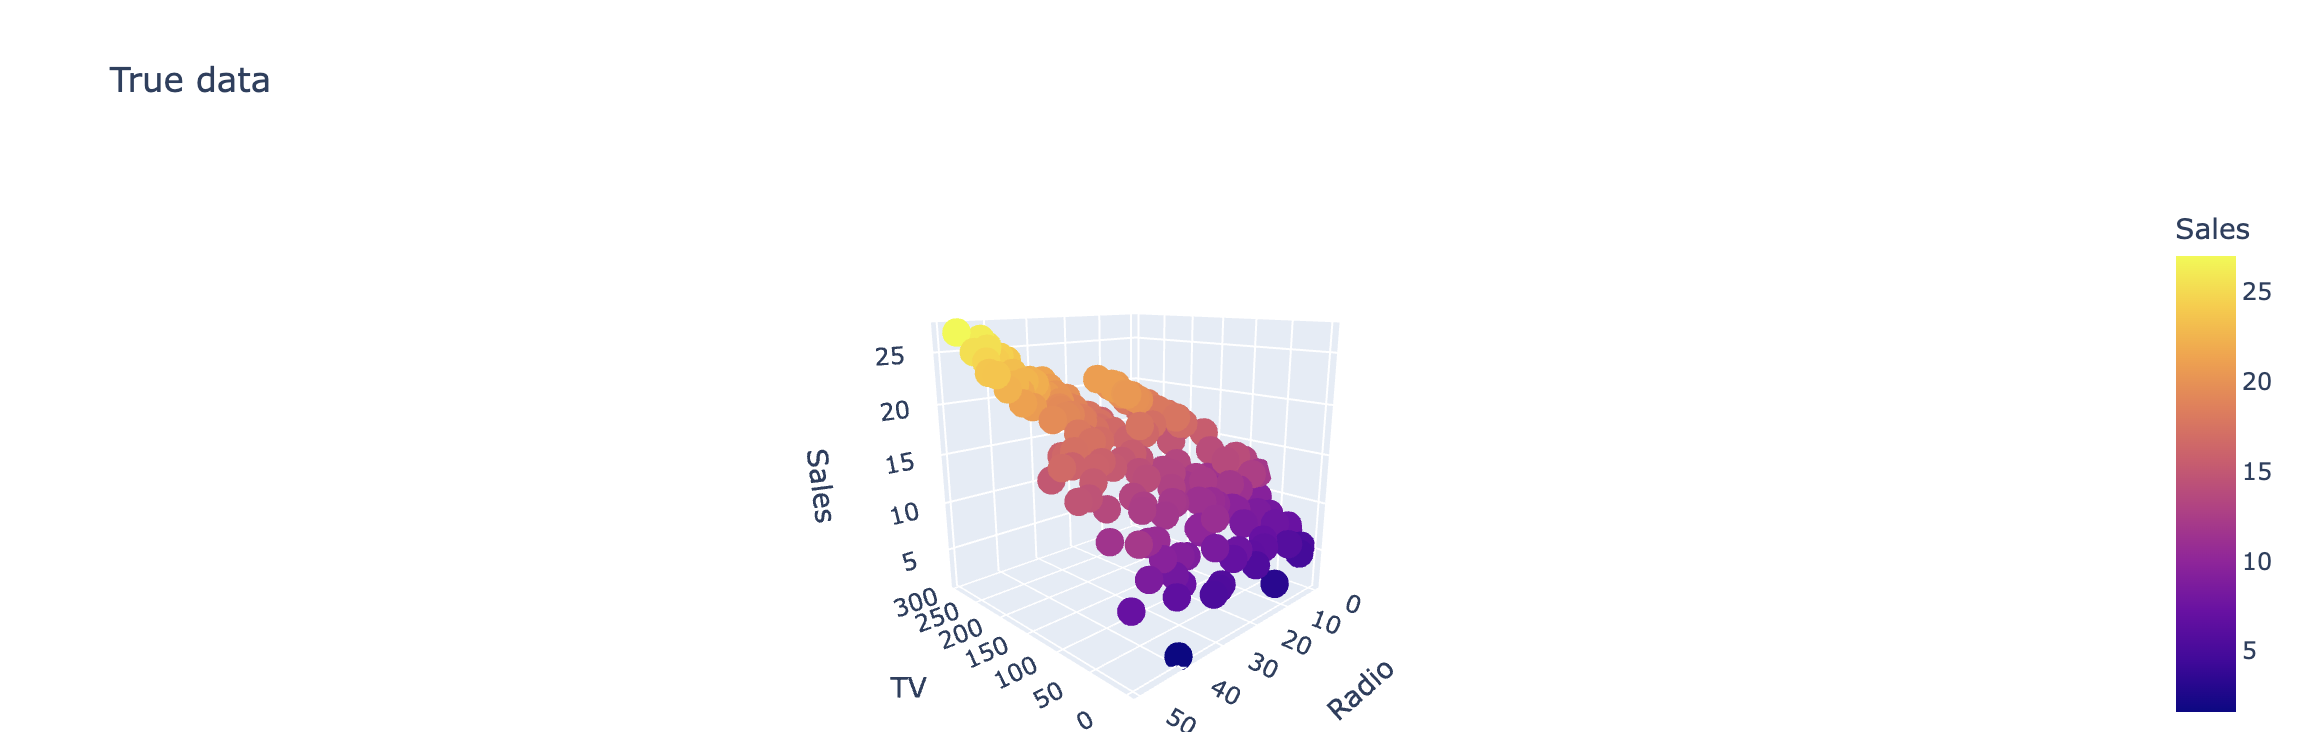
> image pasted as markdown

In [12]:
# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

## Linear Regression

In [13]:
# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print('Intercept: ',lr.intercept_)
print('Coef: ',lr.coef_)
print('R2 Score: ',r2_score(y_test, y_pred_lr))

Intercept:  4.499831369256476
Coef:  [0.05536768 0.102883   0.00233839]
R2 Score:  0.8407131803267818


In [20]:
# plane of Regression
x_range = np.linspace(df['TV'].min(), df['TV'].max(), 15)
y_range = np.linspace(df['Radio'].min(), df['Radio'].max(), 15)

xx,yy = np.meshgrid(x_range, y_range)
news_mean = df['Newspaper'].mean()
news_col = np.full(xx.ravel().shape, news_mean)

pred_input = np.c_[xx.ravel(), yy.ravel(), news_col]
zz = lr.predict(pred_input).reshape(xx.shape)

fig = px.scatter_3d(df, x = df['TV'],
                    y = df['Radio'],
                    z = df['Sales'],
                    # color=df['Sales'],
                    # color_continuous_scale='viridis',
                    title='True data')
fig.add_surface(x = x_range, y = y_range, z = zz)

fig.show()


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



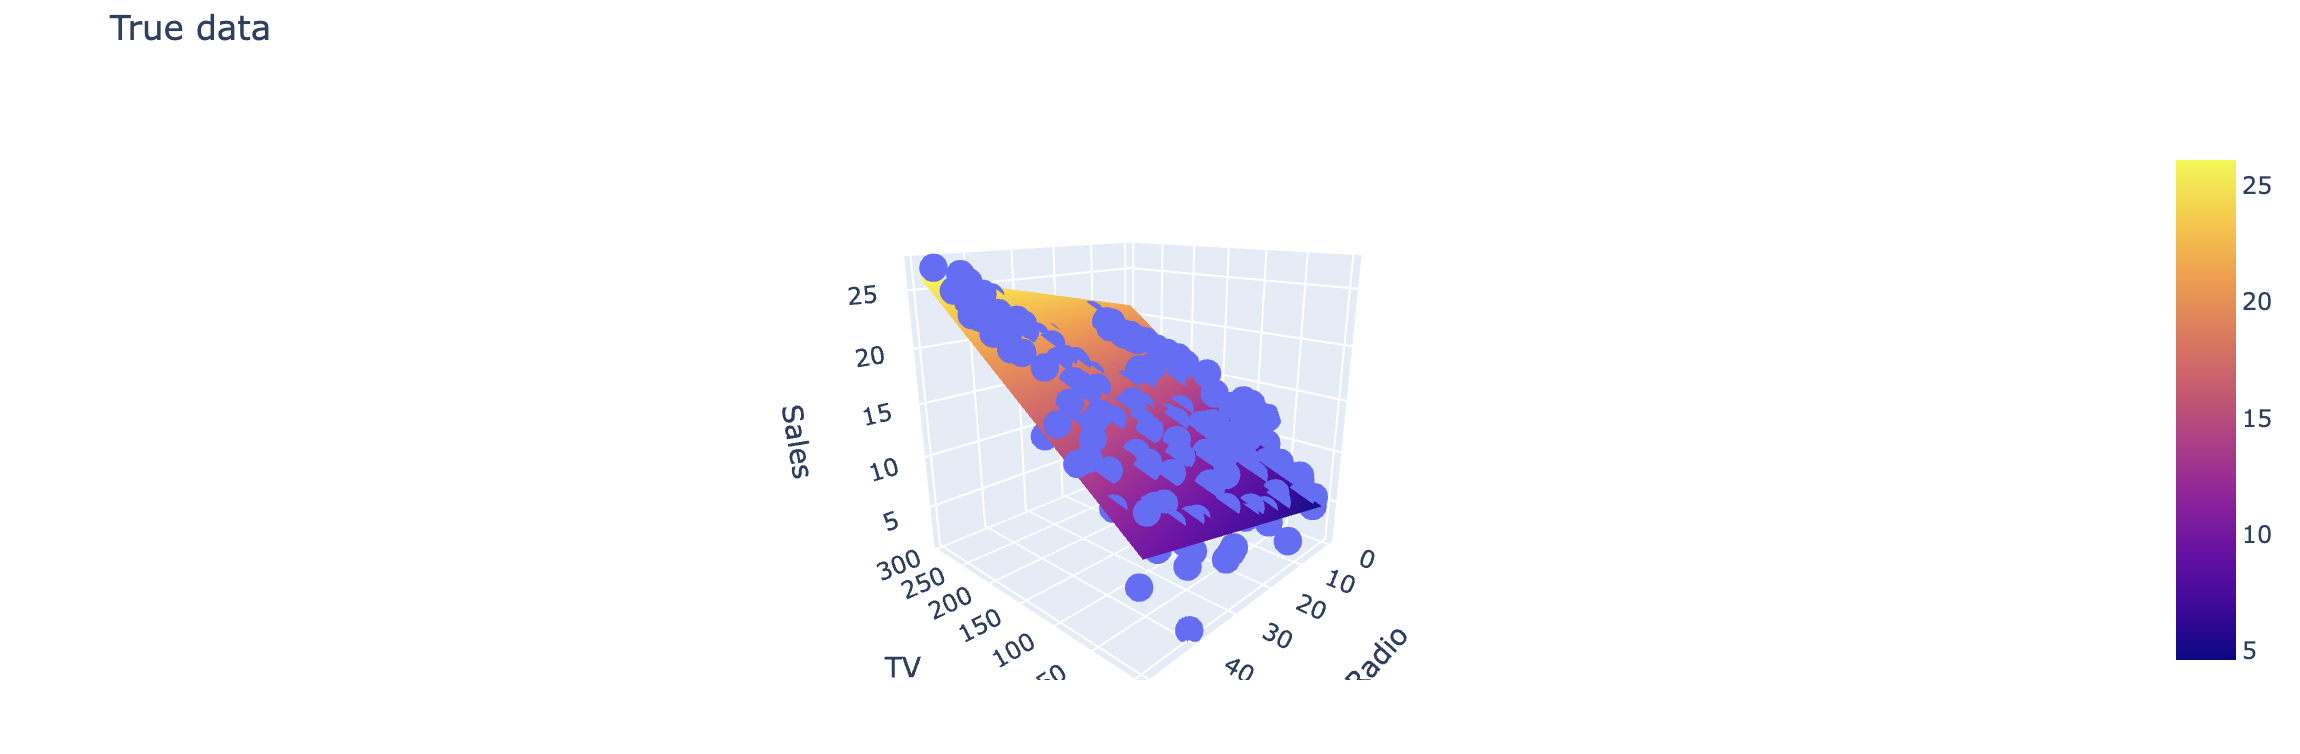
> image pasted as markdown

## Ridge Regression

In [25]:
r = Ridge(alpha = 0.001)
r.fit(x_train, y_train)
y_pred = r.predict(x_test)

print('Intercept: ',r.intercept_)
print('Coef: ',r.coef_)
print('R2 Score: ',r2_score(y_test, y_pred))

Intercept:  4.499831422326389
Coef:  [0.05536768 0.102883   0.00233839]
R2 Score:  0.8407131789536897


In [26]:
# plane of Regression
x_range = np.linspace(df['TV'].min(), df['TV'].max(), 15)
y_range = np.linspace(df['Radio'].min(), df['Radio'].max(), 15)

xx,yy = np.meshgrid(x_range, y_range)
news_mean = df['Newspaper'].mean()
news_col = np.full(xx.ravel().shape, news_mean)

pred_input = np.c_[xx.ravel(), yy.ravel(), news_col]
zz = r.predict(pred_input).reshape(xx.shape)

fig = px.scatter_3d(df, x = df['TV'],
                    y = df['Radio'],
                    z = df['Sales'],
                    color=df['Sales'],
                    color_continuous_scale='blues',
                    title='True data')
fig.add_surface(x = x_range, y = y_range, z = zz)

fig.show()


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but Ridge was fitted with feature names



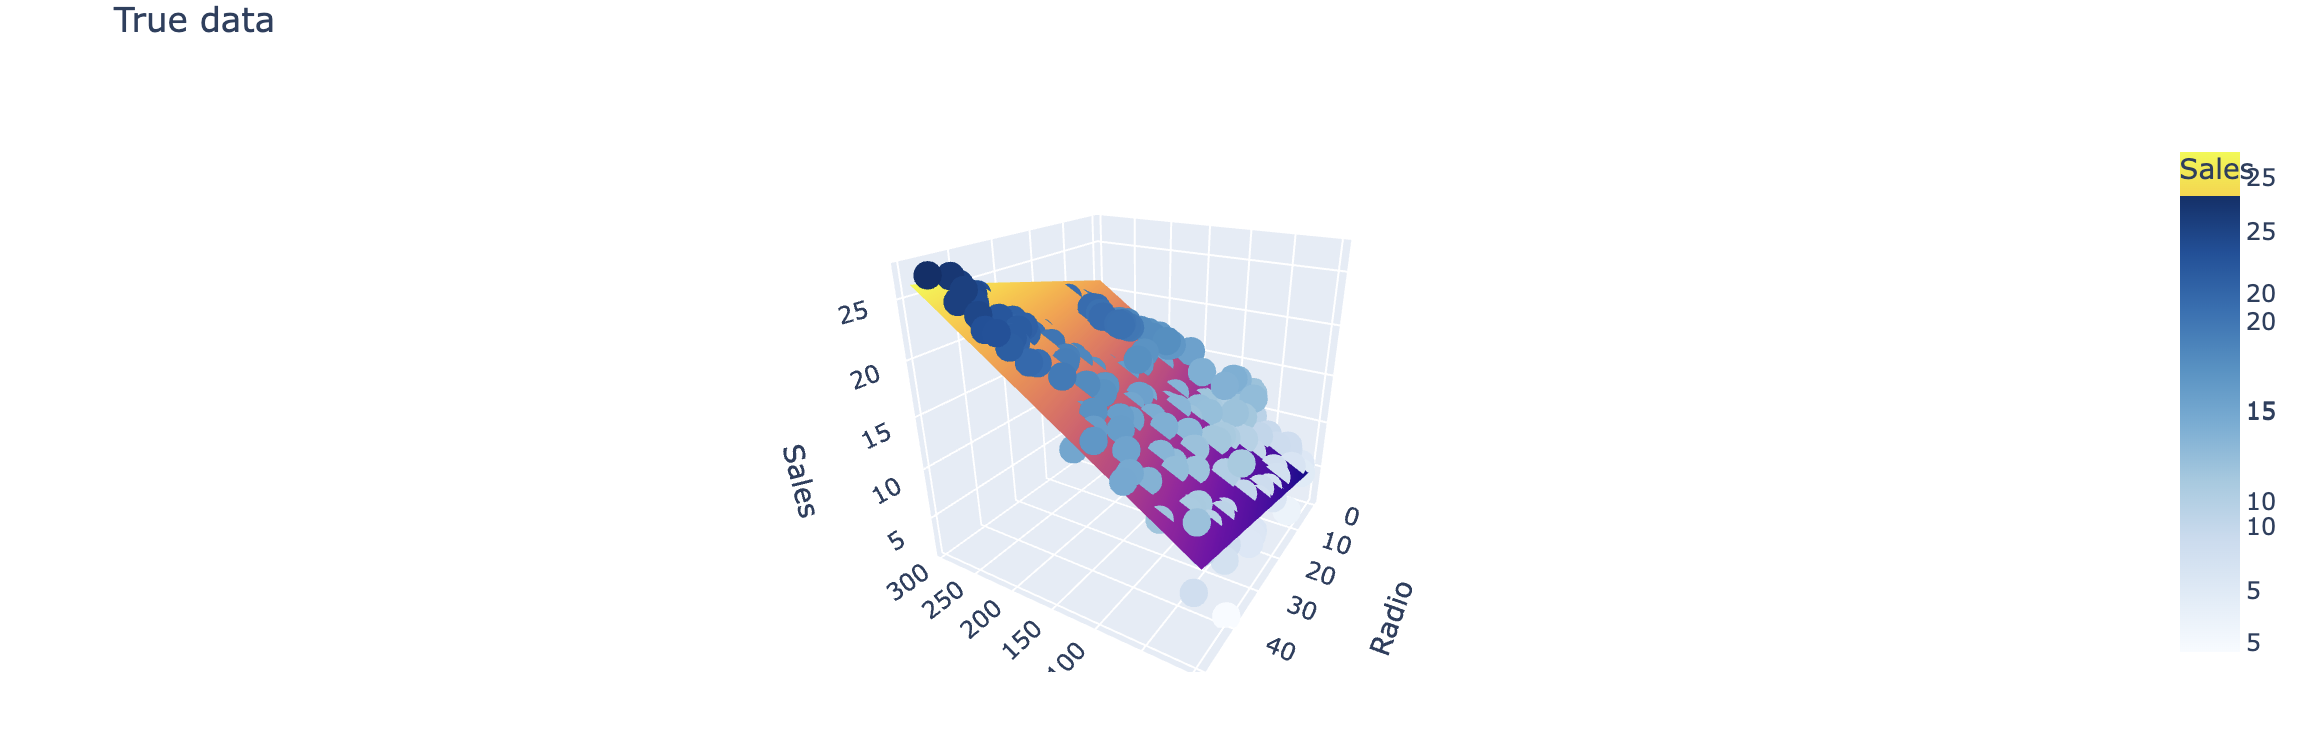
> image pasted as markdown

In [27]:
# Comparing R2 scores of Linear vs Ridge
linear = r2_score(y_test, y_pred_lr)
ridge = r2_score(y_test, y_pred)

print(linear)
print(ridge)
print(ridge >= linear)

0.8407131803267818
0.8407131789536897
False
